## 2. Data Understanding

### 2.1 Data Loading and Basic Exploration
In this initial step, I load the dataset into a Pandas DataFrame and inspect its overall structure. The goal is to understand the number of records (rows), the available features (columns), their data types (numerical vs. categorical), and to get a general feel for the raw data before any cleaning or preprocessing.


In [28]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/raw/adult.csv')

#  Display the first 5 rows to visually inspect the data format
print("First 5 Rows of the Dataset:")
display(df.head())

# Check the dataset structure (row count, column names, and data types)
print("Dataset Information")
df.info()

First 5 Rows of the Dataset:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


#### 2.1.1 Observations from Initial Data Exploration

After looking at the first few rows (`head()`) and getting a summary of the dataset (`info()`), I noticed several important things:

**1. Dataset Size:**  
The dataset contains **32,561 entries** and **15 features**.

**2. Features and Their Types:**  
The features can be roughly divided into **6 numerical** (`int64`) and **9 categorical/text** (`str` or `object`) columns. Here’s a quick overview:  

- **`age`** *(int64)*: Age of the individual.  
- **`workclass`** *(str)*: General type of employment (e.g., Private, Government).  
- **`fnlwgt`** *(int64)*: "Final weight" – the number of people this entry represents according to the census.  
- **`education`** *(str)*: Highest education level (e.g., HS-grad, Bachelors).  
- **`education.num`** *(int64)*: Numeric representation of education, useful for machine learning models.  
- **`marital.status`** *(str)*: Marital status of the individual.  
- **`occupation`** *(str)*: Specific job or profession.  
- **`relationship`** *(str)*: Role in the family.  
- **`race`** *(str)*: Individual’s race.  
- **`sex`** *(str)*: Gender.  
- **`capital.gain`** *(int64)*: Income from investments or other non-wage sources.  
- **`capital.loss`** *(int64)*: Losses from investments.  
- **`hours.per.week`** *(int64)*: Number of working hours per week.  
- **`native.country`** *(str)*: Country of origin.  
- **`income`** *(str)*: **Target variable** – whether someone earns `>50K` or `<=50K` annually.

**3. Data Quality Issue:**  
At first glance, the `info()` output suggests there are no missing values, since all columns show 32,561 non-null entries. However, looking more closely at the data, I can see that some missing values are actually recorded as **`?`** . This is something I’ll need to clean up before modeling.

### 2.2 Data Quality Checks

In [30]:
# Missing values per column (true NaN/None)
missing_per_col = df.isna().sum().sort_values(ascending=False)
print("Missing values per column (NaN/None):")
display(missing_per_col.to_frame("missing_count"))

Missing values per column (NaN/None):


,missing_count
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


#### 2.2.1 Missing Values

The output shows that the dataset does not contain any true `NaN` or `None` values in any column. At this stage, the dataset appears complete when checked with standard missing-value detection methods.

In [31]:
# 2) Check for hidden missing values in all columns
hidden_missing_all = pd.DataFrame(index=df.columns)

# Count occurrences of '?' in each column
hidden_missing_all["question_mark_?"] = [(df[c].astype(str).str.strip() == "?").sum() for c in df.columns]

# Count occurrences of blank strings in each column
hidden_missing_all["blank_string"] = [(df[c].astype(str).str.strip() == "").sum() for c in df.columns]

print("\nHidden missing values in all columns:")
display(hidden_missing_all)


Hidden missing values in all columns:


,question_mark_?,blank_string
age,0,0
workclass,1836,0
fnlwgt,0,0
education,0,0
education.num,0,0
marital.status,0,0
occupation,1843,0
relationship,0,0
race,0,0
sex,0,0


#### 2.2.2 Hidden Missing Values

This check shows that several missing values are stored as `?` rather than as standard null values. The columns `workclass`, `occupation`, and `native.country` contain the most hidden missing entries. I decided not to remove these rows in the Data Understanding stage, because that could unnecessarily reduce the dataset size. Instead, I will handle them later during data preparation using a suitable strategy .

In [32]:
# 3) Check for duplicate rows
dup_rows = df[df.duplicated()]
dup_count = dup_rows.shape[0]
print(f"\nTotal duplicate rows: {dup_count}")

# Show at least 5 duplicate rows if they exist
if dup_count > 0:
    print("\nSample duplicate rows (up to 5):")
    display(dup_rows.head(5))
else:
    print("No duplicate rows found.")


Total duplicate rows: 24

Sample duplicate rows (up to 5):


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
8453,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
8645,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
12202,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
14346,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
15603,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K


#### 2.2.3 Duplicate Rows

I found 24 duplicate rows in the dataset, which is very small compared to the total number of records. Because of this, I decided **not to remove them during this initial analysis**. If later I find that these duplicates negatively affect model performance, I can handle them at that stage.

Interestingly, none of the articles I reviewed explicitly mentioned removing duplicate rows, so this decision is also consistent with the literature.

In [33]:
# 4) Basic validity checks
invalid_age = df[(df["age"] <= 0) | (df["age"] > 100)]
invalid_hours = df[(df["hours.per.week"] <= 0) | (df["hours.per.week"] > 100)]
invalid_edu_num = df[(df["education.num"] < 1) | (df["education.num"] > 16)]
invalid_capital = df[(df["capital.gain"] < 0) | (df["capital.loss"] < 0)]

print("\nBasic validity checks:")
print(f"Invalid age rows: {len(invalid_age)}")
print(f"Invalid hours.per.week rows: {len(invalid_hours)}")
print(f"Invalid education.num rows: {len(invalid_edu_num)}")
print(f"Invalid negative capital rows: {len(invalid_capital)}")



Basic validity checks:
Invalid age rows: 0
Invalid hours.per.week rows: 0
Invalid education.num rows: 0
Invalid negative capital rows: 0


#### 2.2.4 Basic Validity Checks

I performed basic validity checks to make sure that the numeric values fall within reasonable ranges.

The output shows zero invalid rows for `age`, `hours.per.week`, `education.num`, `capital.gain`, and `capital.loss`. This suggests that the dataset is clean with respect to these basic numeric constraints.

### 2.3 Numerical Feature Analysis

In [34]:
num_cols = df.select_dtypes(include="number").columns
print("Numeric columns:", list(num_cols))
df[num_cols].describe().T

Numeric columns: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


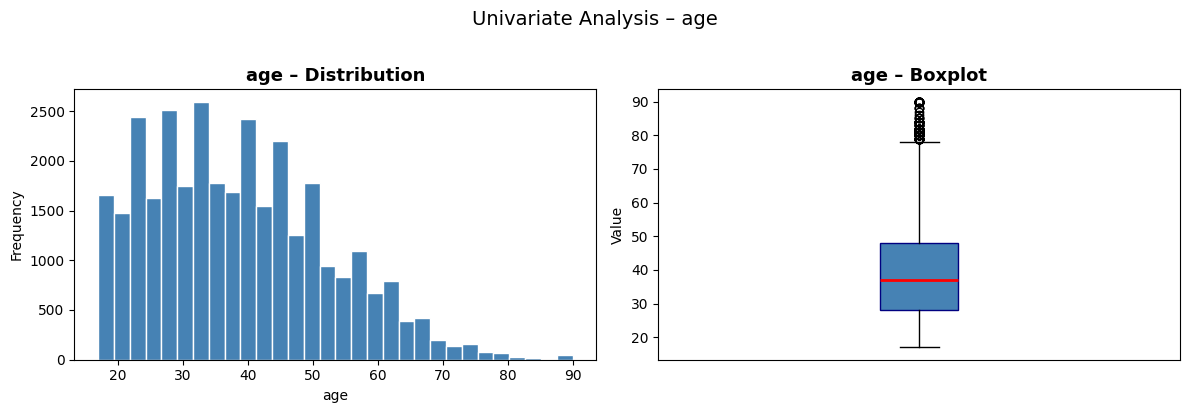


── age ──
count    32561.00
mean        38.58
std         13.64
min         17.00
25%         28.00
50%         37.00
75%         48.00
max         90.00



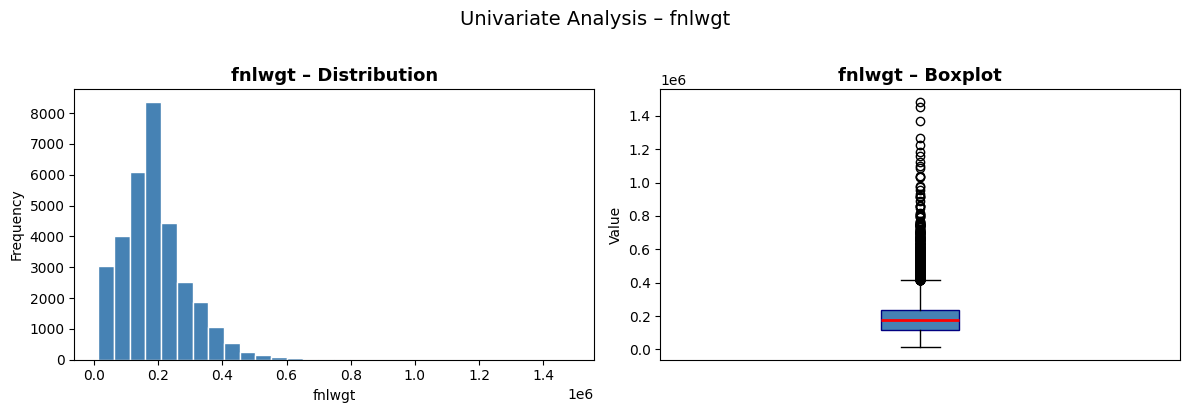


── fnlwgt ──
count      32561.00
mean      189778.37
std       105549.98
min        12285.00
25%       117827.00
50%       178356.00
75%       237051.00
max      1484705.00



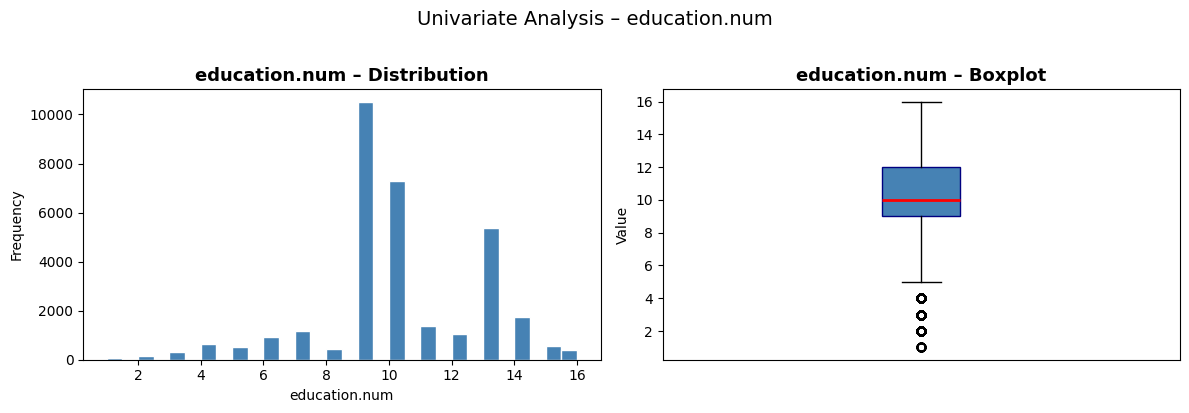


── education.num ──
count    32561.00
mean        10.08
std          2.57
min          1.00
25%          9.00
50%         10.00
75%         12.00
max         16.00



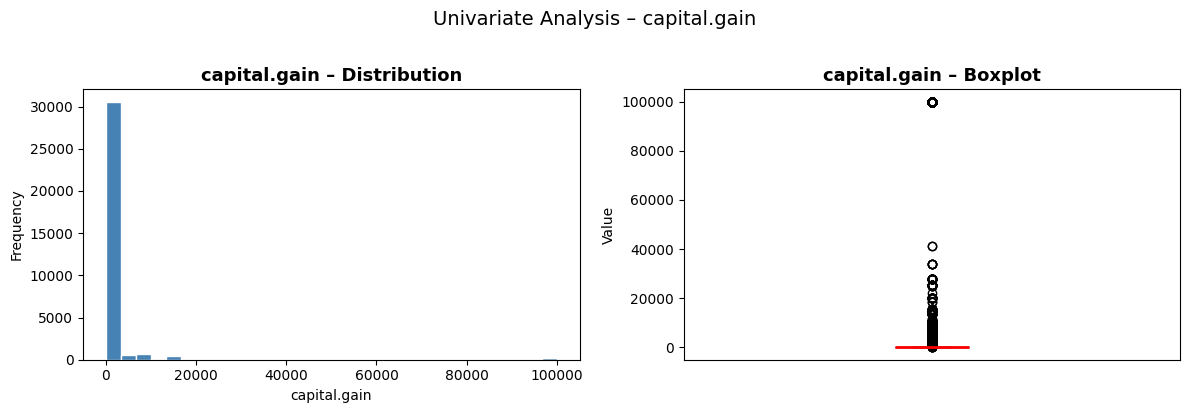


── capital.gain ──
count    32561.00
mean      1077.65
std       7385.29
min          0.00
25%          0.00
50%          0.00
75%          0.00
max      99999.00



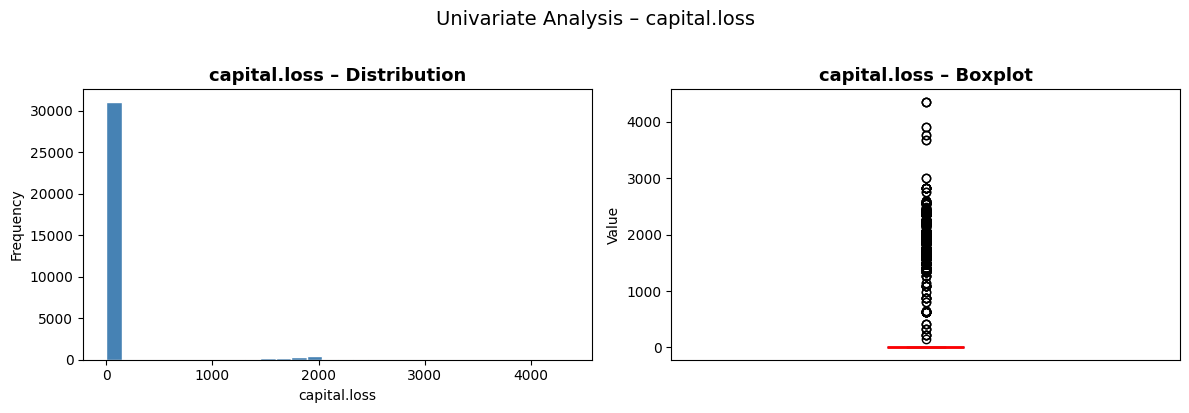


── capital.loss ──
count    32561.00
mean        87.30
std        402.96
min          0.00
25%          0.00
50%          0.00
75%          0.00
max       4356.00



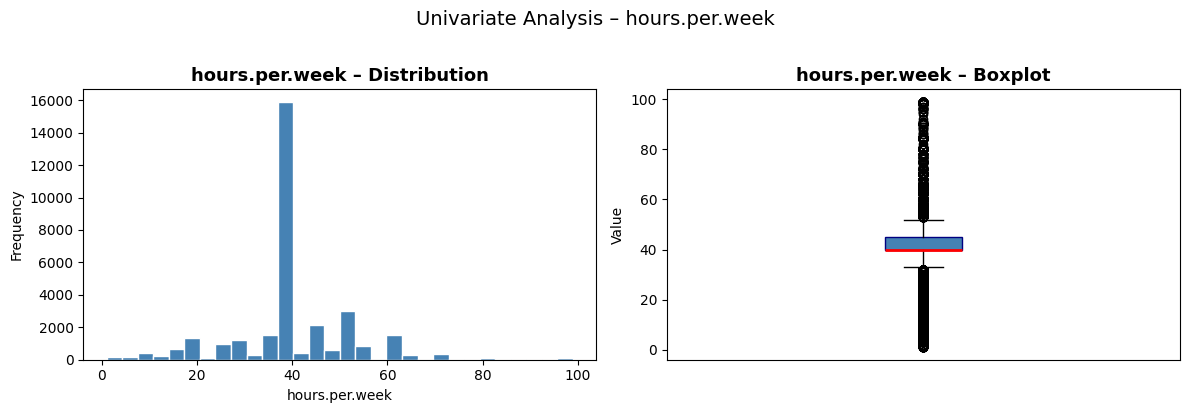


── hours.per.week ──
count    32561.00
mean        40.44
std         12.35
min          1.00
25%         40.00
50%         40.00
75%         45.00
max         99.00



In [35]:
# ── 1. Numeric: Histogram + Boxplot side-by-side ─────────────────────────────
for col in num_cols:
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    ax_hist.hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax_hist.set_title(f"{col} – Distribution", fontsize=13, fontweight="bold")
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel("Frequency")

    # Boxplot
    ax_box.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", color="navy"),
                   medianprops=dict(color="red", linewidth=2))
    ax_box.set_title(f"{col} – Boxplot", fontsize=13, fontweight="bold")
    ax_box.set_ylabel("Value")
    ax_box.set_xticks([])

    plt.suptitle(f"Univariate Analysis – {col}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary stats
    print(f"\n── {col} ──")
    print(df[col].describe().round(2).to_string())
    print()

#### 2.3.1 Numerical Features Analysis

To better understand the numeric features in the dataset, I looked at the descriptive statistics and also visualized their distributions using boxplots. This helped me understand the typical values of each feature and identify possible outliers or skewed distributions.

- **`age`**: The average age in the dataset is about **38 years**, with values ranging from **17 to 90**. Most individuals fall roughly between **28 and 48 years old**. The boxplot shows a fairly balanced distribution, with a few older outliers above around 70.

- **`fnlwgt`**: This feature has a very wide range and a large standard deviation, which means the values are highly spread out. The boxplot also shows many high outliers. Since this variable represents a **census weight**, such variation is expected and does not necessarily indicate an error.

- **`education.num`**: Values range from **1 to 16**, with an average of around **10**, which roughly corresponds to a high school level of education. The boxplot shows that the values are fairly concentrated and there are no extreme outliers.

- **`capital.gain` and `capital.loss`**: Both features have means close to zero, while their maximum values are quite large. The boxplots clearly show that most values are **zero**, with only a small number of very large values. This indicates that both variables are **strongly right-skewed**, meaning only a few individuals report significant capital gains or losses.

- **`hours.per.week`**: The average working time is around **40 hours per week**, which matches a typical full-time job. The boxplot confirms that most people cluster around this value, although there are some outliers representing people who work very few or very many hours.

### 2.4 Categorical Feature Analysis

In [36]:
obj_cols = df.select_dtypes(include="object").columns
print("Categorical columns:", list(obj_cols))
df[obj_cols].describe().T

Categorical columns: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']


/var/folders/mj/jxy0r72n1wv1fg54ygdhhjx00000gn/T/ipykernel_7505/1444452182.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


,count,unique,top,freq
workclass,32561,9,Private,22696
education,32561,16,HS-grad,10501
marital.status,32561,7,Married-civ-spouse,14976
occupation,32561,15,Prof-specialty,4140
relationship,32561,6,Husband,13193
race,32561,5,White,27816
sex,32561,2,Male,21790
native.country,32561,42,United-States,29170
income,32561,2,<=50K,24720


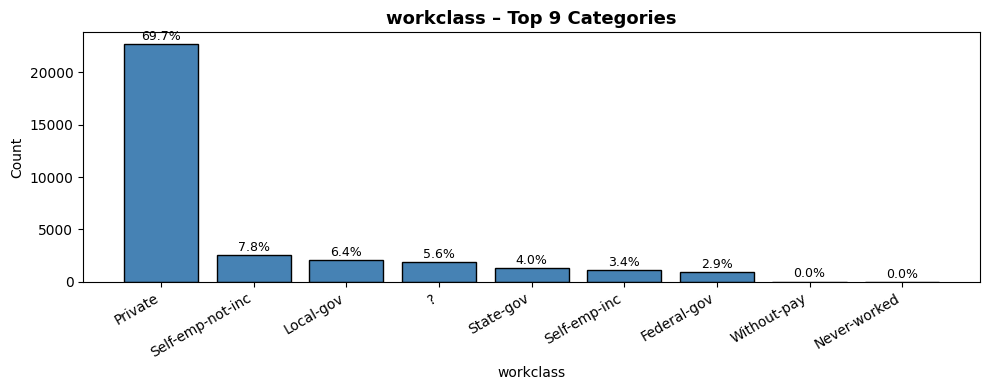


── workclass ──


,count,percentage (%)
workclass,,
Private,22696,69.70
Self-emp-not-inc,2541,7.80
Local-gov,2093,6.43
?,1836,5.64
State-gov,1298,3.99
Self-emp-inc,1116,3.43
Federal-gov,960,2.95
Without-pay,14,0.04
Never-worked,7,0.02


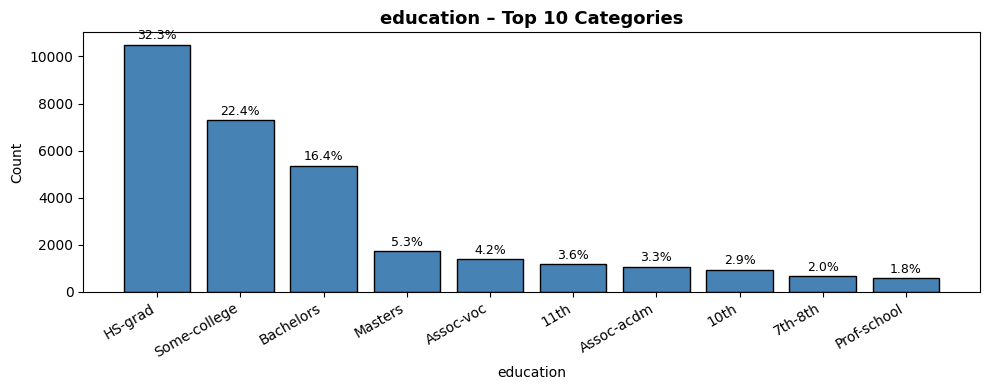


── education ──


,count,percentage (%)
education,,
HS-grad,10501,32.25
Some-college,7291,22.39
Bachelors,5355,16.45
Masters,1723,5.29
Assoc-voc,1382,4.24
11th,1175,3.61
Assoc-acdm,1067,3.28
10th,933,2.87
7th-8th,646,1.98


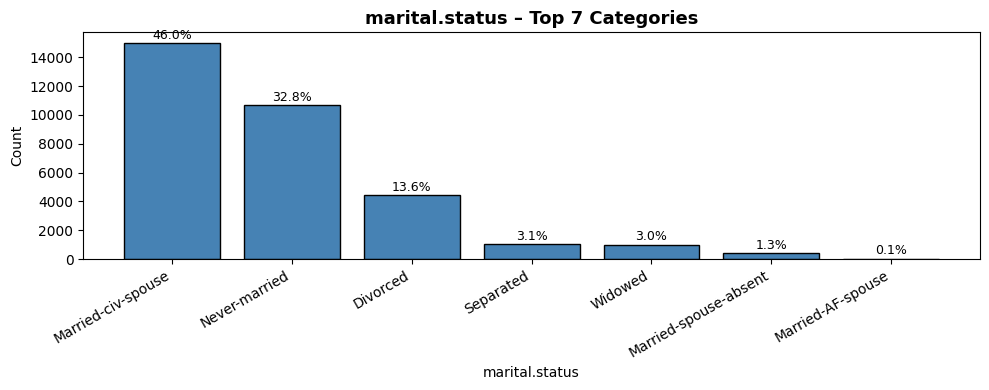


── marital.status ──


,count,percentage (%)
marital.status,,
Married-civ-spouse,14976,45.99
Never-married,10683,32.81
Divorced,4443,13.65
Separated,1025,3.15
Widowed,993,3.05
Married-spouse-absent,418,1.28
Married-AF-spouse,23,0.07


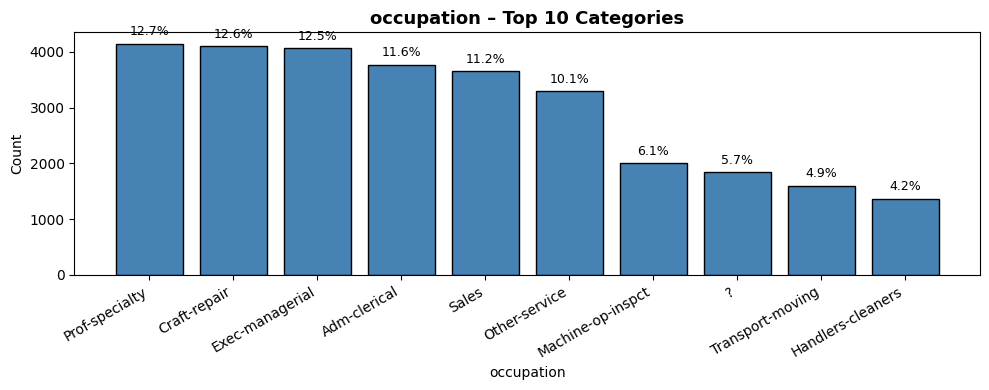


── occupation ──


,count,percentage (%)
occupation,,
Prof-specialty,4140,12.71
Craft-repair,4099,12.59
Exec-managerial,4066,12.49
Adm-clerical,3770,11.58
Sales,3650,11.21
Other-service,3295,10.12
Machine-op-inspct,2002,6.15
?,1843,5.66
Transport-moving,1597,4.90


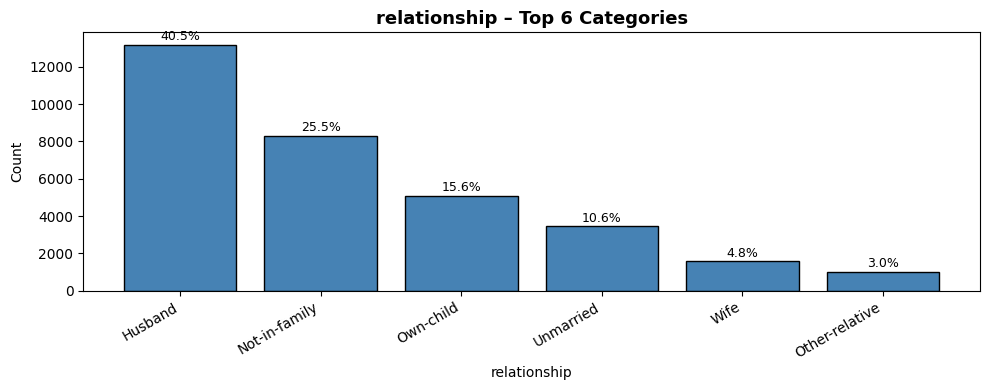


── relationship ──


,count,percentage (%)
relationship,,
Husband,13193,40.52
Not-in-family,8305,25.51
Own-child,5068,15.56
Unmarried,3446,10.58
Wife,1568,4.82
Other-relative,981,3.01


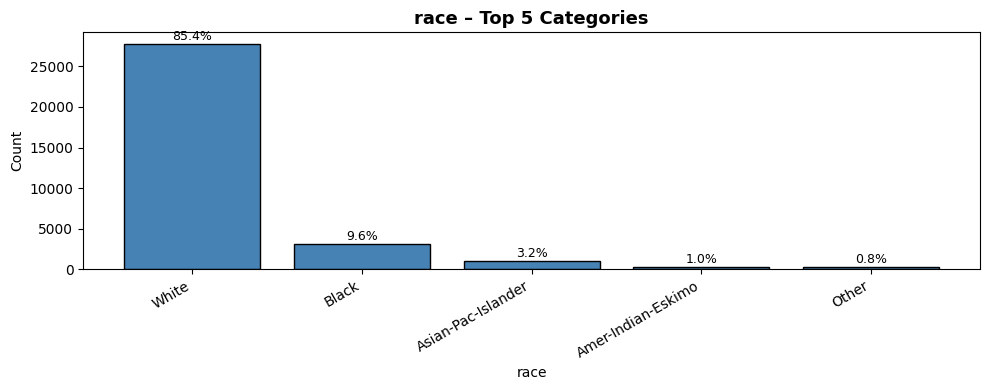


── race ──


,count,percentage (%)
race,,
White,27816,85.43
Black,3124,9.59
Asian-Pac-Islander,1039,3.19
Amer-Indian-Eskimo,311,0.96
Other,271,0.83


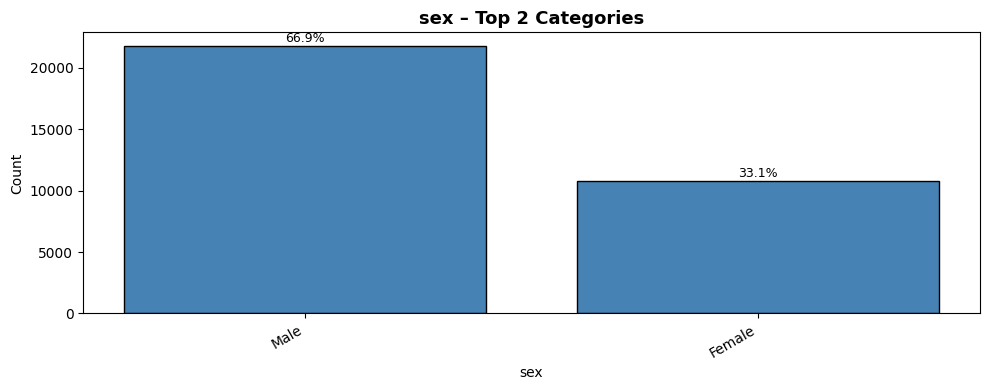


── sex ──


,count,percentage (%)
sex,,
Male,21790,66.92
Female,10771,33.08


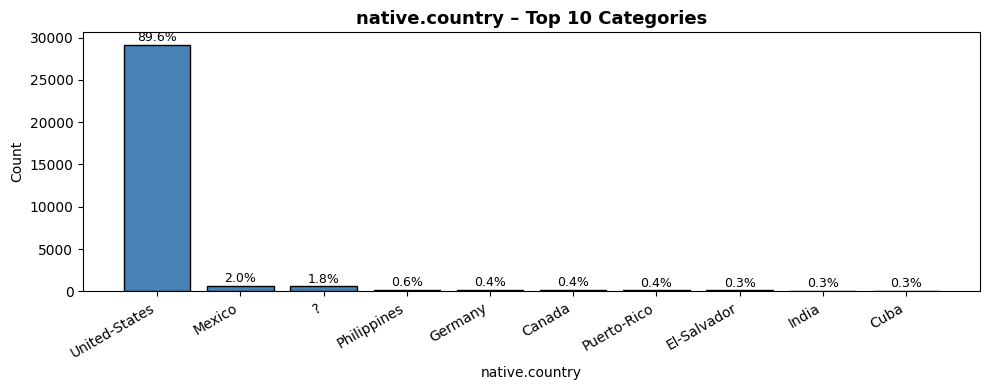


── native.country ──


,count,percentage (%)
native.country,,
United-States,29170,89.59
Mexico,643,1.97
?,583,1.79
Philippines,198,0.61
Germany,137,0.42
Canada,121,0.37
Puerto-Rico,114,0.35
El-Salvador,106,0.33
India,100,0.31


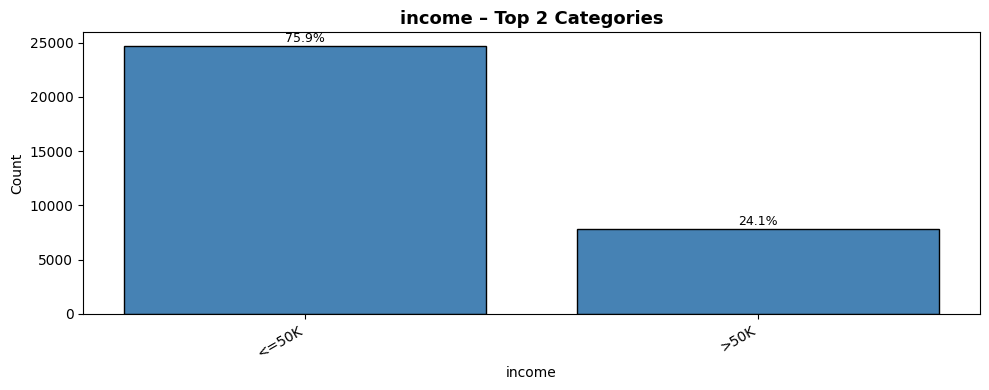


── income ──


,count,percentage (%)
income,,
<=50K,24720,75.92
>50K,7841,24.08


In [37]:
# ── 2. Categorical: Count plot + top-categories table ────────────────────────
TOP_N = 10  # show at most top-10 categories per column

for col in obj_cols:
    value_counts = df[col].value_counts()
    top = value_counts.head(TOP_N)

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(top.index, top.values, color="steelblue", edgecolor="black")
    ax.set_title(f"{col} – Top {min(TOP_N, len(top))} Categories", fontsize=13, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.xticks(rotation=30, ha="right")

    # Annotate percentage on each bar
    total = len(df)
    for bar, cnt in zip(bars, top.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.003,
                f"{cnt / total * 100:.1f}%",
                ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

    # Top-categories summary table
    top_df = pd.DataFrame({
        "count": top,
        "percentage (%)": (top / total * 100).round(2)
    })
    print(f"\n── {col} ──")
    display(top_df)
    print()

#### 2.4.1 Categorical Features Overview

Looking at the categorical summary statistics, a few important patterns appear.

- **Private** is the most common category in `workclass`, which suggests that most individuals in the dataset work in the private sector.
- In `education`, **HS-grad** is the most frequent value, meaning a large portion of individuals have a high school level education.
- **Married-civ-spouse** appears most often in `marital.status`, showing that many individuals in the dataset are married.
- The dataset is heavily dominated by **White** in the `race` column and **Male** in the `sex` column.
- In `native.country`, most individuals are from the **United States**, while many other countries appear only rarely.
- The target variable `income` is **imbalanced**, since the number of people earning `<=50K` is much higher than those earning `>50K`.

Overall, some categorical variables contain many categories (such as `native.country` and `education`), while others have only a few values. This is something I will consider later during preprocessing and modeling.

### 2.5 Unique Values and Label Quality

In [38]:
# Categorical columns (use existing obj_cols if available)
cat_cols = obj_cols if "obj_cols" in globals() else df.select_dtypes(include="object").columns

# 1) Number of unique values per categorical column
unique_counts = df[cat_cols].nunique(dropna=False).sort_values(ascending=False)
print("Unique value count per categorical column:")
display(unique_counts.to_frame("n_unique"))

# 2) Label quality audit: spaces/case inconsistencies
audit_rows = []
for c in cat_cols:
    s = df[c].astype(str)

    has_leading_trailing_spaces = (s != s.str.strip()).any()
    has_double_spaces = s.str.contains(r"\s{2,}", regex=True).any()

    # Case inconsistency check:
    # if multiple raw labels collapse into one lowercase+stripped label
    normalized = s.str.strip().str.lower()
    variants = s.groupby(normalized).nunique()
    case_or_space_variants = int((variants > 1).sum())

    audit_rows.append({
        "column": c,
        "n_unique": s.nunique(dropna=False),
        "has_leading_trailing_spaces": bool(has_leading_trailing_spaces),
        "has_double_spaces": bool(has_double_spaces),
        "normalized_groups_with_multiple_raw_labels": case_or_space_variants
    })

label_audit = pd.DataFrame(audit_rows).set_index("column")
print("\nCategory label audit:")
display(label_audit)

# 3) Inspect actual labels in each categorical column
for c in cat_cols:
    labels = sorted(df[c].astype(str).unique())
    print(f"\n{c} ({len(labels)} unique labels):")
    print(labels)

Unique value count per categorical column:


,n_unique
native.country,42
education,16
occupation,15
workclass,9
marital.status,7
relationship,6
race,5
sex,2
income,2



Category label audit:


,n_unique,has_leading_trailing_spaces,has_double_spaces,normalized_groups_with_multiple_raw_labels
column,,,,
workclass,9,False,False,0
education,16,False,False,0
marital.status,7,False,False,0
occupation,15,False,False,0
relationship,6,False,False,0
race,5,False,False,0
sex,2,False,False,0
native.country,42,False,False,0
income,2,False,False,0



workclass (9 unique labels):
['?', 'Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']

education (16 unique labels):
['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']

marital.status (7 unique labels):
['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']

occupation (15 unique labels):
['?', 'Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']

relationship (6 unique labels):
['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']

race (5 unique labels):
['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Blac

#### 2.5.1 Unique Value and Label Quality Findings

- Count the number of unique values per column.
- Check for hidden inconsistencies like leading/trailing spaces, double spaces, or different letter cases.
- Inspect the actual labels in each column to see if any cleaning or merging might be needed later.

This step helps me identify potential preprocessing actions, such as grouping rare categories or correcting inconsistent labels, before training the models.

I also checked for label inconsistencies (extra spaces, double spaces, or different cases) and found that most columns were consistent.

The results show that some columns, like `native.country` and `education`, have many categories. Later in preprocessing, I might consider grouping rare countries and merging similar education levels.

### 2.6 Target Variable Understanding

Class Distribution of 'income':


,count,percentage (%)
income,,
<=50K,24720,75.92
>50K,7841,24.08



Baseline Accuracy (majority class): 75.92%
Imbalance Ratio (majority / minority): 3.15:1

  Class imbalance detected! Consider using stratified sampling, class weights, or resampling techniques.


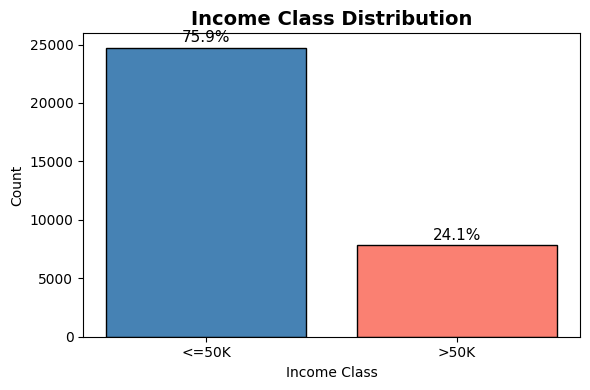

In [39]:
# Target variable analysis: income
target_col = "income"

# 1) Class distribution
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

class_dist = pd.DataFrame({
    "count": class_counts,
    "percentage (%)": class_pct.round(2)
})
print("Class Distribution of 'income':")
display(class_dist)

# 2) Baseline accuracy (majority class classifier)
baseline_acc = class_pct.max()
print(f"\nBaseline Accuracy (majority class): {baseline_acc:.2f}%")

# 3) Imbalance ratio
majority = class_counts.max()
minority = class_counts.min()
imbalance_ratio = majority / minority
print(f"Imbalance Ratio (majority / minority): {imbalance_ratio:.2f}:1")

if imbalance_ratio > 1.5:
    print("\n  Class imbalance detected! Consider using stratified sampling, class weights, or resampling techniques.")
else:
    print("\n Classes are fairly balanced.")

# 4) Bar chart of class distribution
fig_target, ax_target = plt.subplots(figsize=(6, 4))
bars = ax_target.bar(class_counts.index, class_counts.values, color=["steelblue", "salmon"], edgecolor="black")
ax_target.set_title("Income Class Distribution", fontsize=14, fontweight="bold")
ax_target.set_xlabel("Income Class")
ax_target.set_ylabel("Count")

for bar, pct in zip(bars, class_pct.values):
    ax_target.text(bar.get_x() + bar.get_width() / 2,
                   bar.get_height() + 200,
                   f"{pct:.1f}%",
                   ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

#### 2.6.1 Target Variable Analysis (Income)

In this step, I examined the distribution of the target variable `income`. The results show that **75.9%** of individuals earn `<=50K`, while **24.1%** earn `>50K`.

This indicates that the dataset is **imbalanced**, with the majority class being about **3.15 times larger** than the minority class. The baseline accuracy is **75.92%**, meaning a simple model that always predicts `<=50K` would already achieve this accuracy.

To address this issue during the modeling stage, techniques such as **stratified sampling**, **class weighting**, or **resampling methods** (e.g., oversampling the minority class) can be considered. Similar strategies were also mentioned in the related studies that analyzed the Adult Income dataset.

### 2.7 Relationship Between Key Features and Income

To support the business objectives, I compared the target variable `income` with the key features `education`, `occupation`, `age`, and `hours.per.week`. I use grouped summary tables and visual comparisons to see which categories and numeric ranges are more associated with earning more than $50K.

Numeric features grouped by income:


age        hours.per.week       
         mean median           mean median
income                                    
<=50K   36.78   34.0          38.84   40.0
>50K    44.25   44.0          45.47   40.0


Income distribution within each education category (%):


income,<=50K,>50K,count
education,,,
Doctorate,25.9,74.1,413
Prof-school,26.6,73.4,576
Masters,44.3,55.7,1723
Bachelors,58.5,41.5,5355
Assoc-voc,73.9,26.1,1382
Assoc-acdm,75.2,24.8,1067
Some-college,81.0,19.0,7291
HS-grad,84.0,16.0,10501
12th,92.4,7.6,433



Income distribution within each occupation category (%):


income,<=50K,>50K,count
occupation,,,
Exec-managerial,51.6,48.4,4066
Prof-specialty,55.1,44.9,4140
Protective-serv,67.5,32.5,649
Tech-support,69.5,30.5,928
Sales,73.1,26.9,3650
Craft-repair,77.3,22.7,4099
Transport-moving,80.0,20.0,1597
Adm-clerical,86.6,13.4,3770
Machine-op-inspct,87.5,12.5,2002


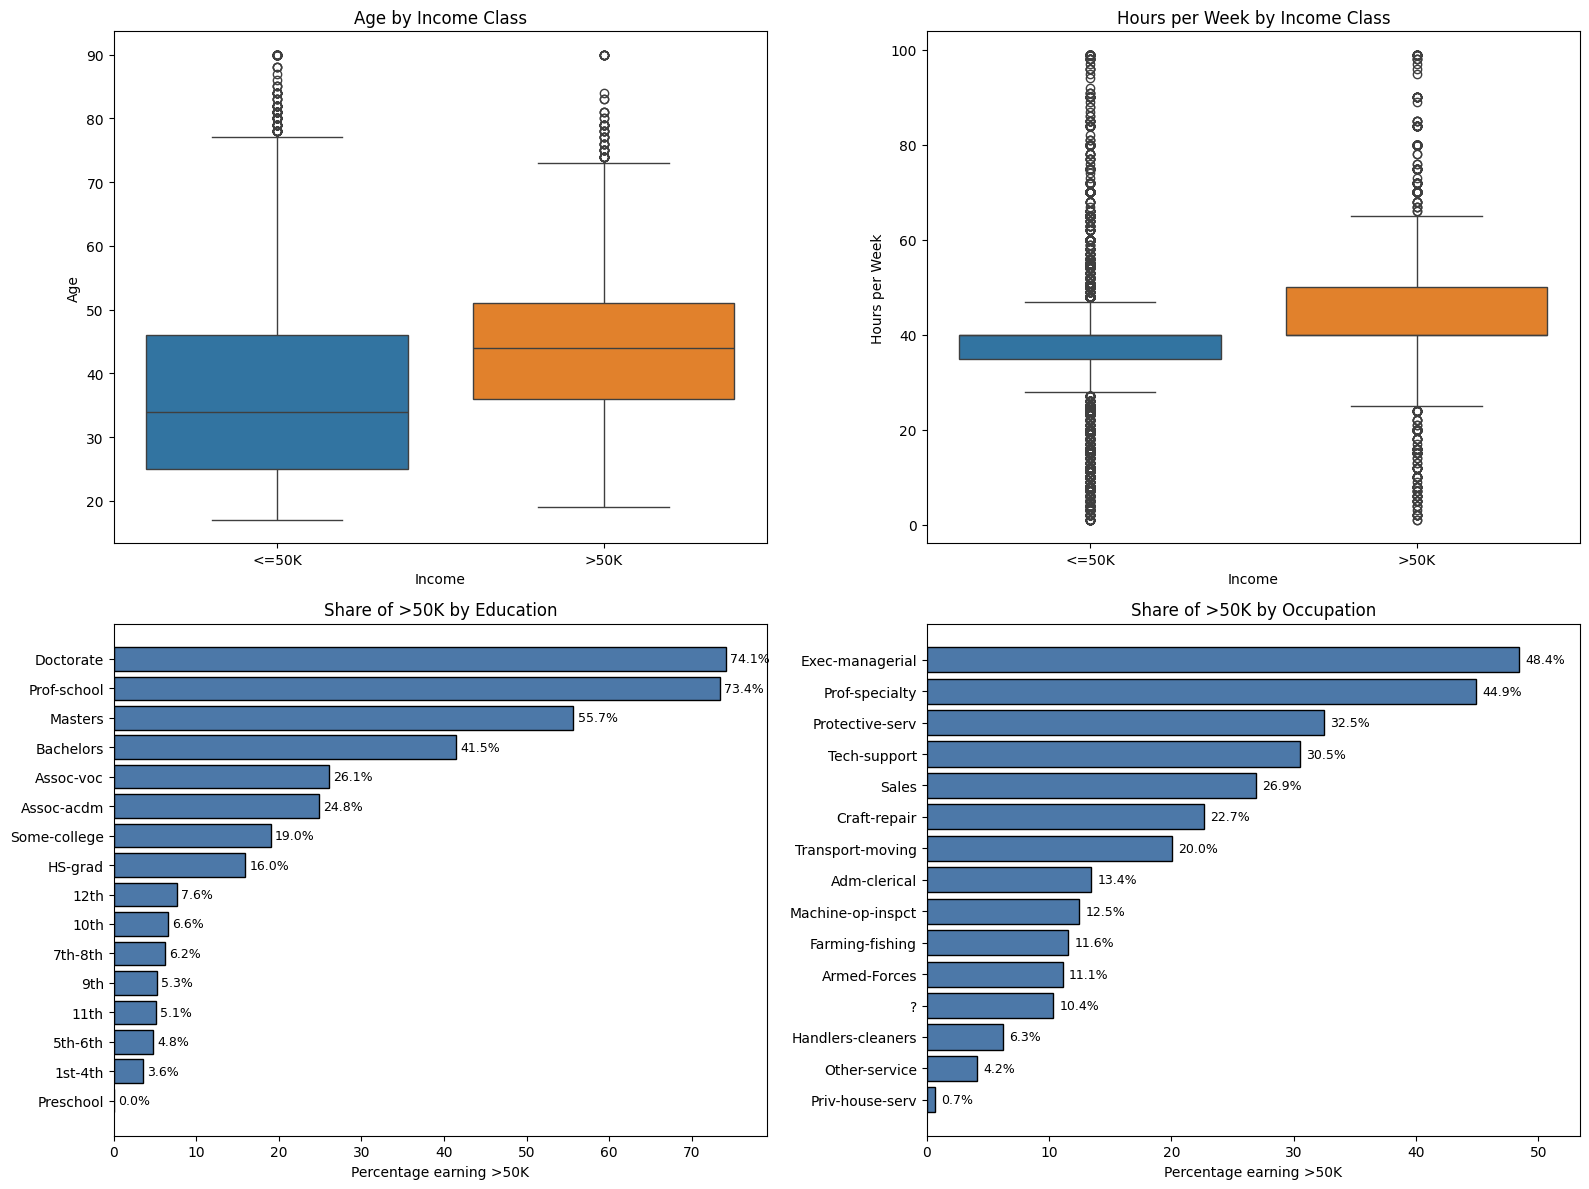

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = "income"
positive_class = ">50K"
numeric_focus = ["age", "hours.per.week"]
categorical_focus = ["education", "occupation"]

numeric_summary = (
    df.groupby(target_col)[numeric_focus]
    .agg(["mean", "median"])
    .round(2)
)
print("Numeric features grouped by income:")
display(numeric_summary)

for feature in categorical_focus:
    share_table = (
        pd.crosstab(df[feature], df[target_col], normalize="index")
        .mul(100)
        .round(1)
        .sort_values(by=positive_class, ascending=False)
    )
    share_table["count"] = df[feature].value_counts()
    print(f"\nIncome distribution within each {feature} category (%):")
    display(share_table)

income_rates = {
    feature: (
        df.groupby(feature)[target_col]
        .apply(lambda values: values.eq(positive_class).mean() * 100)
        .sort_values()
    )
    for feature in categorical_focus
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=df, x=target_col, y="age", ax=axes[0, 0], hue=target_col, legend=False)
axes[0, 0].set_title("Age by Income Class")
axes[0, 0].set_xlabel("Income")
axes[0, 0].set_ylabel("Age")

sns.boxplot(data=df, x=target_col, y="hours.per.week", ax=axes[0, 1], hue=target_col, legend=False)
axes[0, 1].set_title("Hours per Week by Income Class")
axes[0, 1].set_xlabel("Income")
axes[0, 1].set_ylabel("Hours per Week")

for ax, (feature, rates) in zip(axes[1], income_rates.items()):
    bars = ax.barh(rates.index, rates.values, color="#4C78A8", edgecolor="black")
    ax.set_title(f"Share of >50K by {feature.title()}")
    ax.set_xlabel("Percentage earning >50K")
    ax.set_xlim(0, max(45, rates.max() + 5))

    for bar, value in zip(bars, rates.values):
        ax.text(value + 0.5, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

#### 2.7.1 Findings From the Feature-to-Income Comparison

The grouped summaries and plots show that the relationship with income is not random. Higher education categories generally have a larger share of people earning more than $50K, while lower education categories are more concentrated in the `<=50K` class. A similar pattern appears for occupation: managerial and professional roles tend to have a higher proportion of `>50K`, while several manual and service-oriented occupations are more concentrated in `<=50K`.

For the numeric features, the `>50K` group tends to be older on average and also works slightly more hours per week than the `<=50K` group. These patterns are useful because they directly support the business objective of understanding which factors are associated with higher or lower income before moving into the modeling stage.

#### 2.7.2 Correlation Heatmap for Numeric Features

To add another view of the relationships in the dataset, I include a correlation heatmap for the numeric variables and an encoded version of the target. This helps me see which numeric features move together and which ones are more positively or negatively associated with earning more than $50K.

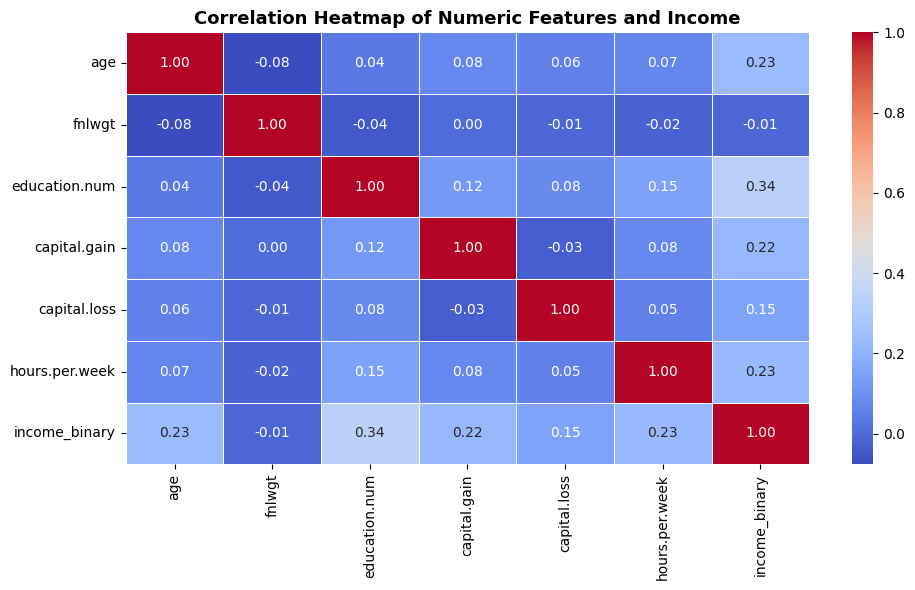

In [40]:
heatmap_df = df.copy()
heatmap_df["income_binary"] = heatmap_df["income"].eq(">50K").astype(int)

corr_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week", "income_binary"]
corr = heatmap_df[corr_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features and Income", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### 2.7.3 Heatmap Interpretation

The correlation heatmap shows that `education.num` has the strongest positive relationship with `income_binary` among the numeric features, with a correlation of about **0.34**. This suggests that a higher education level is more strongly associated with earning more than $50K than the other numeric variables in this analysis.

`Age`, `hours.per.week`, and `capital.gain` also show positive correlations with income, each at a moderate level. This means that older individuals, those who work more hours, and those with higher capital gains are somewhat more likely to belong to the `>50K` income group. In contrast, `fnlwgt` has almost no correlation with income, which suggests that it may not be very informative for distinguishing income classes on its own.

Overall, the heatmap indicates that numeric features do have useful relationships with income, but most of these relationships are moderate rather than very strong. This means income prediction will likely depend on combining several variables together, including both numeric and categorical features.

### 2.8 Fairness-Aware Exploratory Analysis

Because the dataset includes sensitive demographic attributes such as `sex` and `race`, it is important to examine how income is distributed across these groups. This does not mean these differences are causal or fair. It means they should be understood and documented before modeling, because they may reflect historical and social inequalities that could be learned by the model.


Income distribution within each sex group (%):


income,<=50K,>50K,count
sex,,,
Male,69.4,30.6,21790
Female,89.1,10.9,10771



Income distribution within each race group (%):


income,<=50K,>50K,count
race,,,
Asian-Pac-Islander,73.4,26.6,1039
White,74.4,25.6,27816
Black,87.6,12.4,3124
Amer-Indian-Eskimo,88.4,11.6,311
Other,90.8,9.2,271



Income distribution within each marital.status group (%):


income,<=50K,>50K,count
marital.status,,,
Married-civ-spouse,55.3,44.7,14976
Married-AF-spouse,56.5,43.5,23
Divorced,89.6,10.4,4443
Widowed,91.4,8.6,993
Married-spouse-absent,91.9,8.1,418
Separated,93.6,6.4,1025
Never-married,95.4,4.6,10683


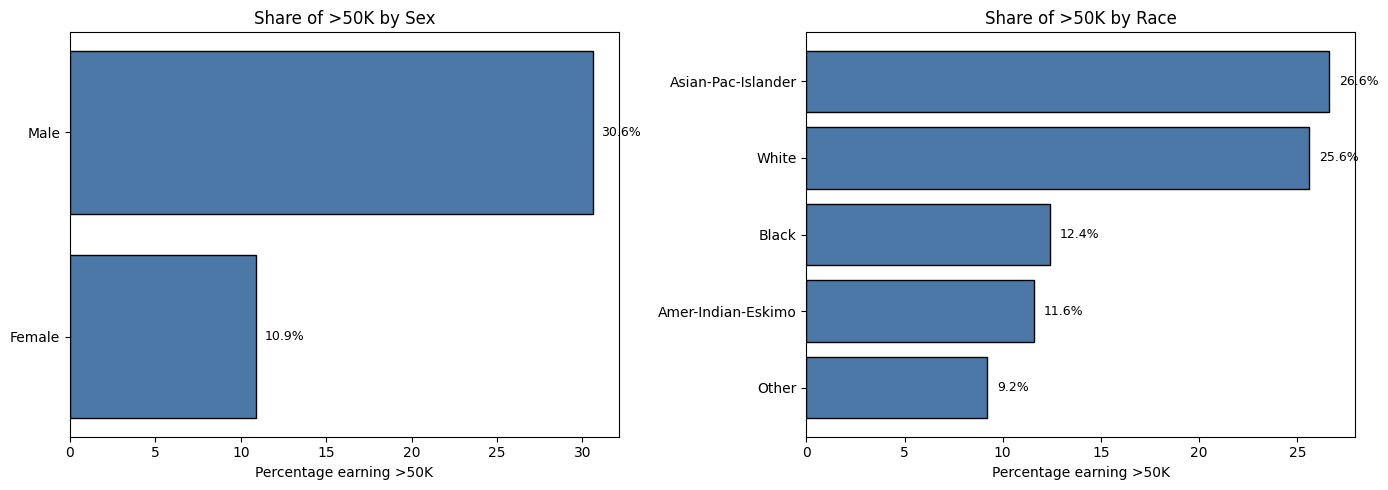

In [41]:
fairness_features = ["sex", "race", "marital.status"]

for feature in fairness_features:
    fairness_table = (
        pd.crosstab(df[feature], df[target_col], normalize="index")
        .mul(100)
        .round(1)
        .sort_values(by=positive_class, ascending=False)
    )
    fairness_table["count"] = df[feature].value_counts()
    print(f"\nIncome distribution within each {feature} group (%):")
    display(fairness_table)

plot_rows = []
for feature in ["sex", "race"]:
    rates = (
        df.groupby(feature)[target_col]
        .apply(lambda values: values.eq(positive_class).mean() * 100)
        .sort_values()
    )
    for group, rate in rates.items():
        plot_rows.append({"feature": feature, "group": group, "pct_gt50k": round(rate, 1)})

plot_df = pd.DataFrame(plot_rows)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature in zip(axes, ["sex", "race"]):
    tmp = plot_df[plot_df["feature"] == feature].sort_values("pct_gt50k")
    bars = ax.barh(tmp["group"], tmp["pct_gt50k"], color="#4C78A8", edgecolor="black")
    ax.set_title(f"Share of >50K by {feature.title()}")
    ax.set_xlabel("Percentage earning >50K")

    for bar, value in zip(bars, tmp["pct_gt50k"]):
        ax.text(value + 0.5, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

#### 2.8.1 Fairness Interpretation

The output shows clear gaps between groups. For example, the share of `>50K` is much higher for males (**30.6%**) than females (**10.9%**), and race groups also differ a lot (`Asian-Pac-Islander` and `White` are highest, while `Black`, `Amer-Indian-Eskimo`, and `Other` are lower).

This matters because the model can learn these patterns and perform differently across groups, even if overall accuracy looks good. Since this dataset comes from U.S. census data in the **1990s**, these gaps should be read as historical patterns, not causal effects. In the evaluation phase, I should report group-level metrics (like precision, recall, and false-negative rate) to check fairness more carefully.

### 2.9 What I Found, Learned, and Will Do Next

In this Data Understanding stage, I tried to answer my business objective and research questions before moving to modeling.

From my analysis, I found that the data can support income prediction, but it also has important issues I cannot ignore, especially hidden missing values and strong class imbalance.

For my first sub-question("Which features have the strongest influence on income prediction?"), I learned that `education`, `occupation`, `age`, and `hours.per.week` are clearly related to income level. These are important features to keep in focus in the next stage.

For my second sub-question("How does class imbalance affect model performance and fairness?"), I found two things: the target classes are imbalanced, and there are visible differences across `sex` and `race` groups. Because of this, in the next step I should not rely on accuracy only, and I should include fairness-aware evaluation.

I also learned from the unique-value analysis that some categorical features (especially `native.country`) have many rare categories. In the next step, I should group rare levels carefully to reduce sparsity and keep the model more stable.

From the correlation analysis, I found that `education.num` has the strongest positive relationship with income among numeric features, while `fnlwgt` is weak. 